# Instructor Effectiveness Modeling

Trying to classify instructors into Low/Medium/High effectiveness tiers based on their batch-level metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

SEED = 42
np.random.seed(SEED)

In [2]:
df = pd.read_csv('data.csv')
print(df.shape)

(2000, 12)


In [3]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [5]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [6]:
print(df.isnull().sum())
print(f'\nduplicates: {df.duplicated().sum()}')

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

duplicates: 0


In [7]:
print(f'instructors: {df["instructor_id"].nunique()}')
print(f'courses:     {df["course_id"].nunique()}')

bpi = df.groupby('instructor_id')['batch_id'].count()
print(f'batches/instructor: min={bpi.min()}, max={bpi.max()}, mean={bpi.mean():.1f}')

instructors: 120
courses:     25
batches/instructor: min=7, max=31, mean=16.7


2k rows, no nulls, no dupes. 120 instructors, 25 courses, 7–31 batches per instructor.

Quick look at how each numeric column is distributed.

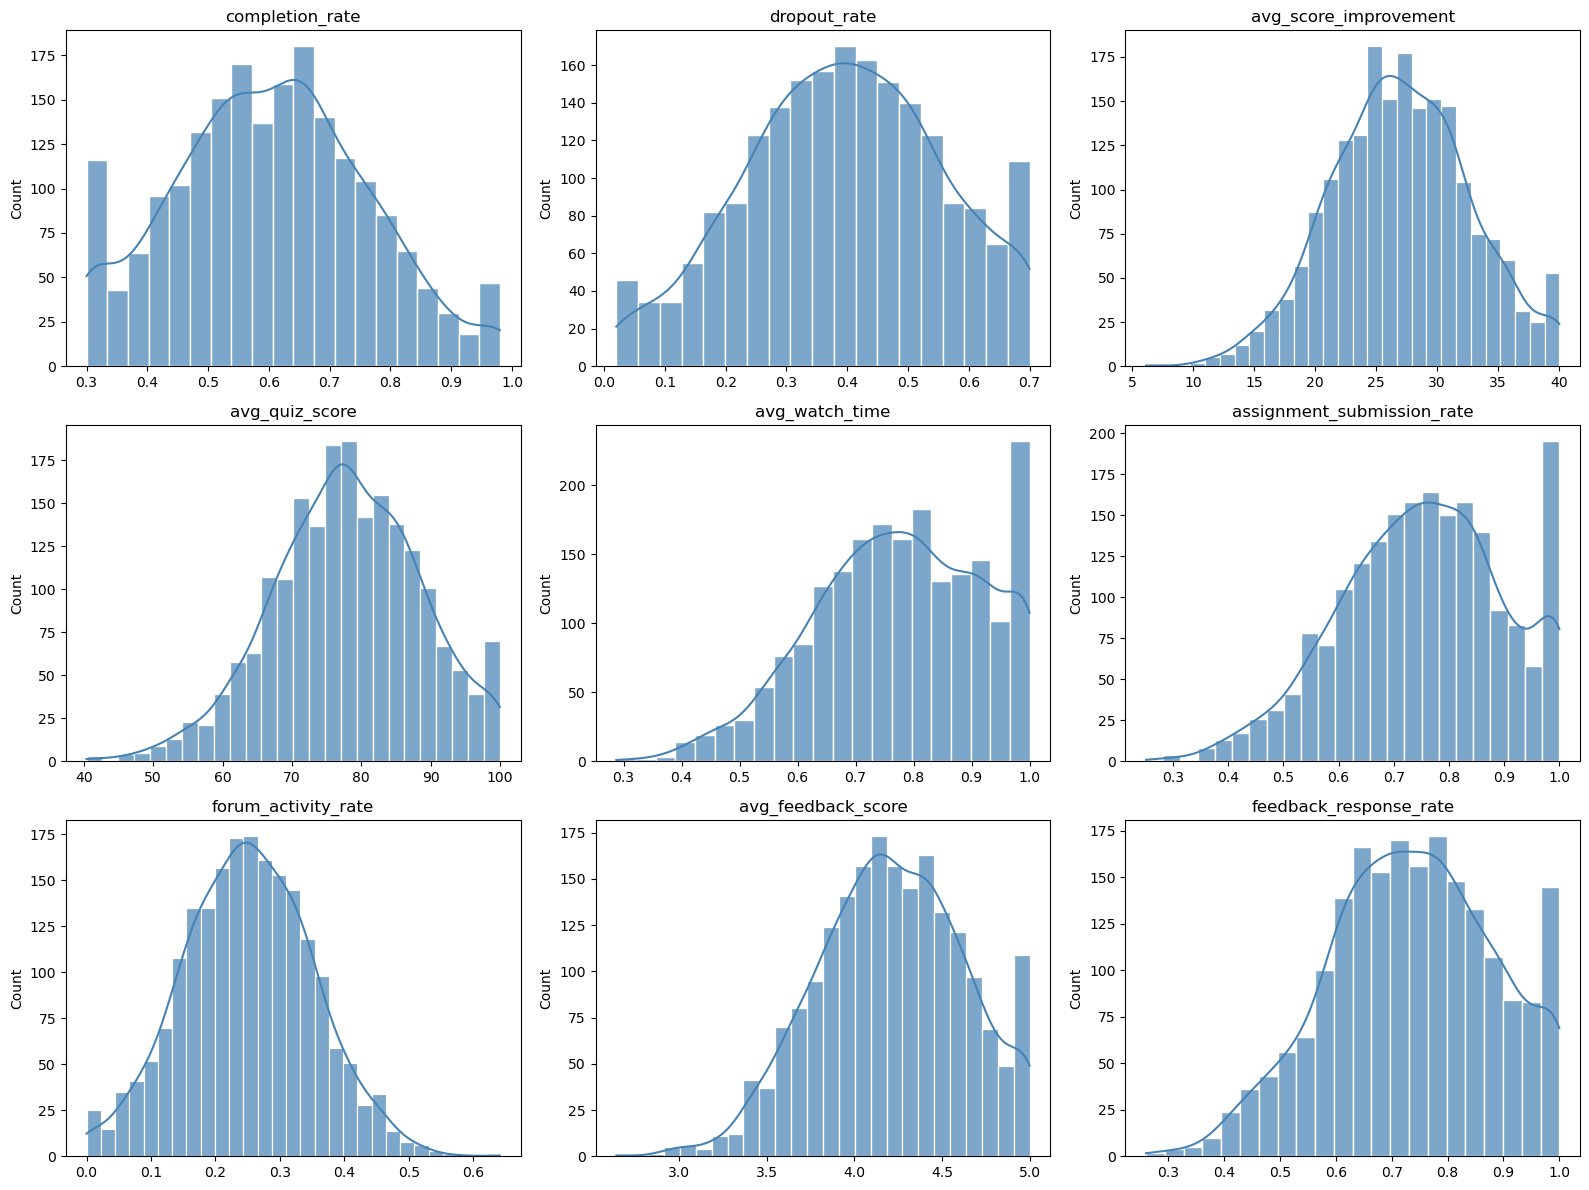

In [8]:
numeric_cols = [
    'completion_rate', 'dropout_rate', 'avg_score_improvement',
    'avg_quiz_score', 'avg_watch_time', 'assignment_submission_rate',
    'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation heatmap.

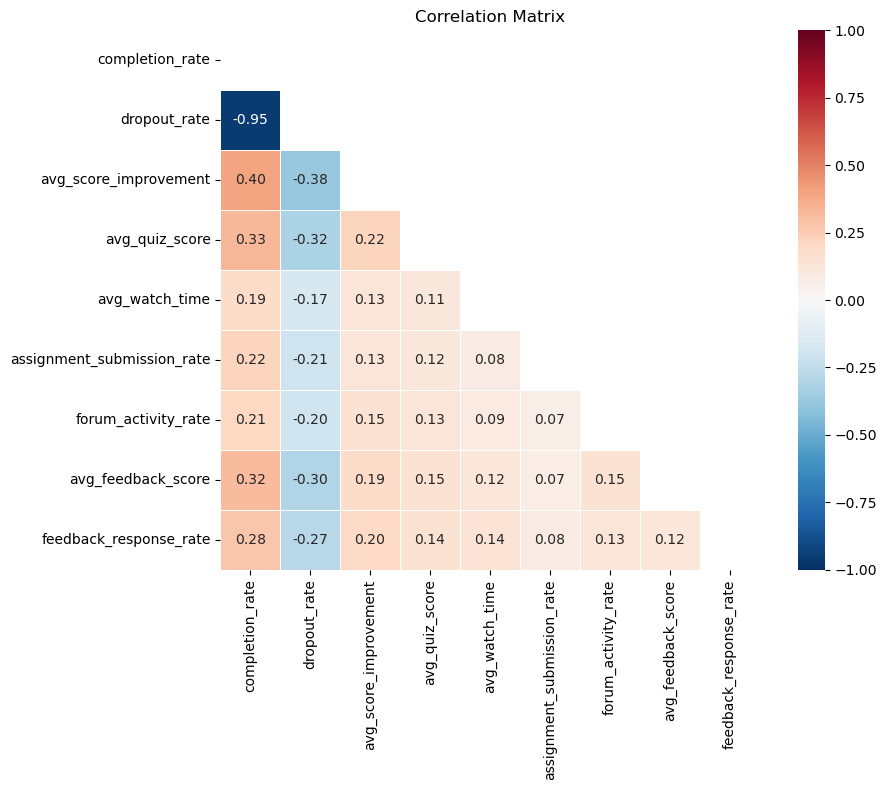

                   f1              f2         r    abs_r
         dropout_rate completion_rate -0.953493 0.953493
avg_score_improvement completion_rate  0.404161 0.404161
avg_score_improvement    dropout_rate -0.381354 0.381354
       avg_quiz_score completion_rate  0.333307 0.333307
   avg_feedback_score completion_rate  0.315394 0.315394


In [9]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# strongest pairs
unstacked = corr.where(mask == False).stack().reset_index()
unstacked.columns = ['f1', 'f2', 'r']
unstacked['abs_r'] = unstacked['r'].abs()
print(unstacked.nlargest(5, 'abs_r').to_string(index=False))

completion_rate and dropout_rate are basically the same thing inverted (r = −0.95), so we'll drop one later. Everything else is pretty weakly correlated which is nice.

Just confirming the completion/dropout thing visually.

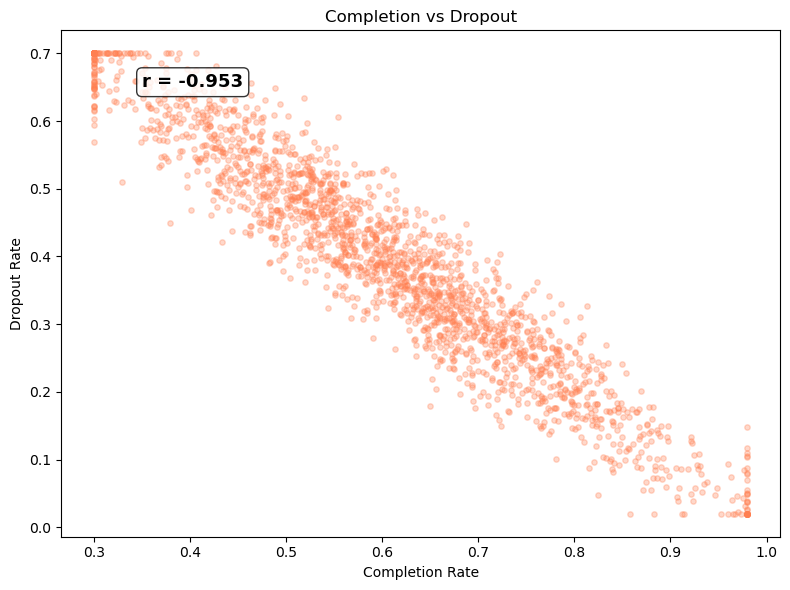

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['completion_rate'], df['dropout_rate'], alpha=0.3, s=15, color='coral')
ax.set_xlabel('Completion Rate')
ax.set_ylabel('Dropout Rate')
ax.set_title('Completion vs Dropout')

r = df['completion_rate'].corr(df['dropout_rate'])
ax.text(0.35, 0.65, f'r = {r:.3f}', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
plt.tight_layout()
plt.savefig('eda_completion_vs_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

How much does feedback score bounce around within a single instructor's batches?

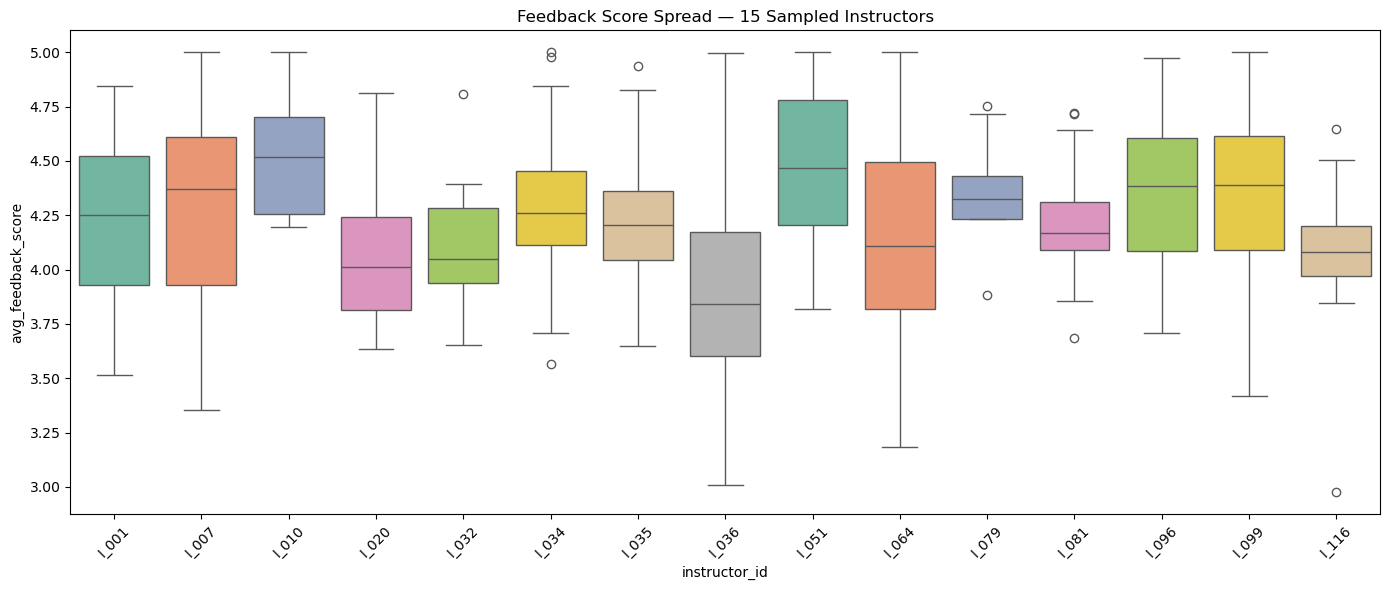

within-instructor std (median): 0.372
overall std:                    0.419


In [11]:
np.random.seed(SEED)
sample_ids = np.random.choice(df['instructor_id'].unique(), 15, replace=False)
sample_ids.sort()
subset = df[df['instructor_id'].isin(sample_ids)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=subset, x='instructor_id', y='avg_feedback_score',
            order=sample_ids, hue='instructor_id', hue_order=sample_ids,
            palette='Set2', legend=False, ax=ax)
ax.set_title('Feedback Score Spread — 15 Sampled Instructors')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_feedback_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

within = df.groupby('instructor_id')['avg_feedback_score'].std().median()
overall = df['avg_feedback_score'].std()
print(f'within-instructor std (median): {within:.3f}')
print(f'overall std:                    {overall:.3f}')

Instructors aren't very consistent — within-instructor std is almost as big as the overall std, so just averaging won't capture the full picture.

Main takeaways: completion and dropout are redundant, there's some clamping at the extremes (0.30 floor, 0.70 ceiling), features are mostly independent, and instructors are pretty noisy across their own batches.

---

Building an effectiveness score from 8 metrics (dropping dropout_rate). Min-max scale everything to 0–1, then weight outcomes at 50%, engagement at 25%, feedback at 25%. Outcomes matter most since they're the actual learning signal.

In [12]:
def scale01(s):
    return (s - s.min()) / (s.max() - s.min())

outcomes = scale01(df[['completion_rate', 'avg_score_improvement', 'avg_quiz_score']]).mean(axis=1)
engagement = scale01(df[['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate']]).mean(axis=1)
feedback = scale01(df[['avg_feedback_score', 'feedback_response_rate']]).mean(axis=1)

df['effectiveness_score'] = 0.50 * outcomes + 0.25 * engagement + 0.25 * feedback
print(df['effectiveness_score'].describe())

count    2000.000000
mean        0.591176
std         0.106431
min         0.192855
25%         0.519049
50%         0.593186
75%         0.661129
max         0.933515
Name: effectiveness_score, dtype: float64


Tertile cuts for Low/Medium/High — keeps the classes balanced.

In [13]:
df['effectiveness_tier'] = pd.qcut(df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High'])
print(df['effectiveness_tier'].value_counts().sort_index())

cuts = df['effectiveness_score'].quantile([1/3, 2/3])
print(f'\ncutoffs: {cuts.iloc[0]:.4f} / {cuts.iloc[1]:.4f}')

effectiveness_tier
Low       667
Medium    666
High      667
Name: count, dtype: int64

cutoffs: 0.5446 / 0.6377


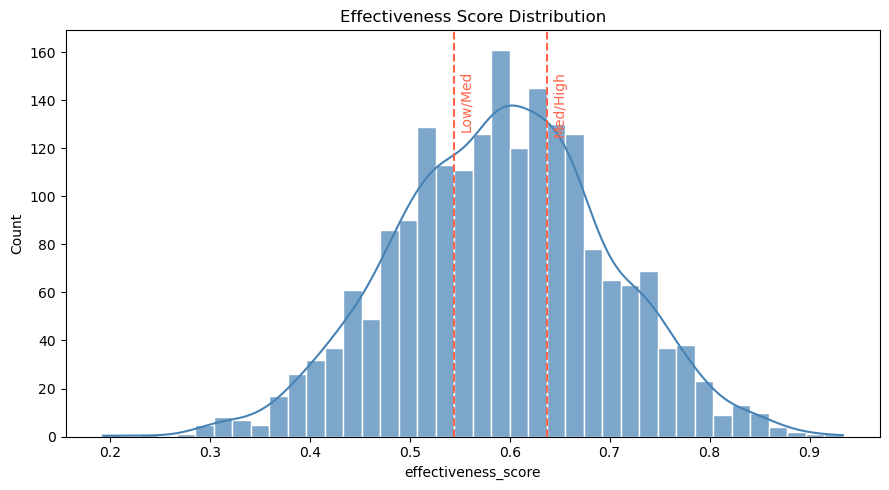

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['effectiveness_score'], bins=40, kde=True, ax=ax,
             color='steelblue', edgecolor='white', alpha=0.7)

for q, lbl in [(1/3, 'Low/Med'), (2/3, 'Med/High')]:
    v = df['effectiveness_score'].quantile(q)
    ax.axvline(v, color='tomato', ls='--', lw=1.5)
    ax.text(v + 0.005, ax.get_ylim()[1] * 0.9, lbl,
            rotation=90, va='top', fontsize=10, color='tomato')

ax.set_title('Effectiveness Score Distribution')
plt.tight_layout()
plt.savefig('eda_effectiveness_score.png', dpi=150, bbox_inches='tight')
plt.show()

---

Aggregating to instructor level — mean and std of each metric across their batches, plus batch count and course count.

In [15]:
metrics = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score',
    'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
    'avg_feedback_score', 'feedback_response_rate'
]

agg = {m: ['mean', 'std'] for m in metrics}
agg['batch_id'] = 'count'
agg['course_id'] = 'nunique'

df_instr = df.groupby('instructor_id').agg(agg)
df_instr.columns = ['_'.join(c).strip('_') for c in df_instr.columns]
df_instr = df_instr.rename(columns={'batch_id_count': 'num_batches',
                                     'course_id_nunique': 'num_courses'})
df_instr = df_instr.reset_index()

print(f'{len(df_instr)} instructors, {df_instr.shape[1]} columns')
df_instr.head()

120 instructors, 19 columns


,instructor_id,completion_rate_mean,completion_rate_std,avg_score_improvement_mean,avg_score_improvement_std,avg_quiz_score_mean,avg_quiz_score_std,avg_watch_time_mean,avg_watch_time_std,assignment_submission_rate_mean,assignment_submission_rate_std,forum_activity_rate_mean,forum_activity_rate_std,avg_feedback_score_mean,avg_feedback_score_std,feedback_response_rate_mean,feedback_response_rate_std,num_batches,num_courses
0,I_001,0.543887,0.084611,26.641462,6.074232,78.900194,8.878089,0.766513,0.131532,0.726893,0.145189,0.240551,0.094695,4.217743,0.388802,0.694858,0.166455,25,16
1,I_002,0.730874,0.103691,30.166242,3.939007,81.737198,9.843168,0.837393,0.112701,0.774394,0.141096,0.289610,0.088573,4.343002,0.440235,0.784338,0.114460,20,10
2,I_003,0.768447,0.120452,29.977813,5.074705,81.590928,11.064673,0.818441,0.158280,0.779606,0.121712,0.296224,0.082414,4.450034,0.386108,0.812132,0.141805,18,14
3,I_004,0.458328,0.067596,22.912021,4.826162,77.680317,12.485520,0.793130,0.126603,0.758317,0.135790,0.226259,0.093217,4.076410,0.400982,0.721460,0.133622,17,10
4,I_005,0.859747,0.090287,32.588652,4.621194,85.828159,7.228742,0.847026,0.108567,0.876942,0.102360,0.333519,0.105278,4.202516,0.304174,0.784197,0.127054,19,13


Didn't want to drop instructors just for having fewer batches, so flagged them instead.

In [16]:
df_instr['low_batch_count'] = df_instr['num_batches'] < 3

std_cols = [c for c in df_instr.columns if c.endswith('_std')]
df_instr[std_cols] = df_instr[std_cols].fillna(0)  # NaN std for single-batch instructors

print(f'flagged: {df_instr["low_batch_count"].sum()}')
print(df_instr['num_batches'].describe())

flagged: 0
count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: num_batches, dtype: float64


Same effectiveness score formula but now at the instructor level using the aggregated means.

In [17]:
def scale01(s):
    return (s - s.min()) / (s.max() - s.min())

out_cols = ['completion_rate_mean', 'avg_score_improvement_mean', 'avg_quiz_score_mean']
eng_cols = ['avg_watch_time_mean', 'assignment_submission_rate_mean', 'forum_activity_rate_mean']
fb_cols = ['avg_feedback_score_mean', 'feedback_response_rate_mean']

df_instr['effectiveness_score'] = (
    0.50 * scale01(df_instr[out_cols]).mean(axis=1) +
    0.25 * scale01(df_instr[eng_cols]).mean(axis=1) +
    0.25 * scale01(df_instr[fb_cols]).mean(axis=1)
)

df_instr['effectiveness_tier'] = pd.qcut(
    df_instr['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High']
)

print(df_instr['effectiveness_tier'].value_counts().sort_index())
print(f'score range: {df_instr["effectiveness_score"].min():.4f} – {df_instr["effectiveness_score"].max():.4f}')

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64
score range: 0.0545 – 0.9644


Grabbed both mean and std because the EDA showed instructors can be all over the place across batches — std captures that consistency (or lack of it).

Turns out low_batch_count is all False anyway since everyone has 7+ batches. The flag's there just in case.

---

Can't use effectiveness_score as a feature since the tiers come directly from it — that'd be leaking the answer.

In [18]:
from sklearn.model_selection import cross_val_score

drop_cols = ['instructor_id', 'effectiveness_score', 'effectiveness_tier', 'low_batch_count']
X = df_instr.drop(columns=drop_cols)
y = df_instr['effectiveness_tier']

print(f'X: {X.shape}, y: {y.shape}')
print(list(X.columns))

X: (120, 18), y: (120,)
['completion_rate_mean', 'completion_rate_std', 'avg_score_improvement_mean', 'avg_score_improvement_std', 'avg_quiz_score_mean', 'avg_quiz_score_std', 'avg_watch_time_mean', 'avg_watch_time_std', 'assignment_submission_rate_mean', 'assignment_submission_rate_std', 'forum_activity_rate_mean', 'forum_activity_rate_std', 'avg_feedback_score_mean', 'avg_feedback_score_std', 'feedback_response_rate_mean', 'feedback_response_rate_std', 'num_batches', 'num_courses']


Only 120 rows so a single test split is kinda noisy — CV will give a better picture.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print(f'train: {len(X_train)}, test: {len(X_test)}')
print(y_train.value_counts().sort_index())

train: 90, test: 30
effectiveness_tier
Low       30
Medium    30
High      30
Name: count, dtype: int64


In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [21]:
lr = LogisticRegression(random_state=SEED, max_iter=1000)
rf = RandomForestClassifier(random_state=SEED, n_estimators=200)

for name, model in [('LogReg', lr), ('RandomForest', rf)]:
    model.fit(X_train_sc, y_train)
    acc = model.score(X_test_sc, y_test)
    cv = cross_val_score(model, X_train_sc, y_train, cv=5)
    print(f'{name:15s} test={acc:.3f}  cv={cv.mean():.3f} ±{cv.std():.3f}')

LogReg          test=0.900  cv=0.844 ±0.054


RandomForest    test=0.867  cv=0.911 ±0.027
